In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_parquet("../data/processed/ml_daily_features.parquet")

# ensuring date is DATETIME and year is INT
df["date"] = pd.to_datetime(df["date"])
df["year"] = df["year"].astype(int)

df.head()
df.dtypes


c:\Users\Christopher\Desktop\Personal Projects\Project 1 Comparing Melbourne's Air Quality\mel-air-norms-now\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


site_id                    object
site_name                  object
pollutant                  object
unit                       object
date               datetime64[ns]
year                        int64
daily_median              float64
daily_mean                float64
roll7                     float64
roll30                    float64
norm_median               float64
delta_abs                 float64
delta_pct                 float64
z                         float64
exceed_pm25_who             int64
exceed_pm10_who             int64
dtype: object

In [3]:
def eval_forecast(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

In [4]:
df["pollutant"] = (
    df["pollutant"]
    .str.upper()
    .str.replace(" ", "")
    .str.replace(".", "")
)

In [5]:
df_pm25 = df[df["pollutant"] == "PM25"].copy()

df_pm25.shape
df_pm25["site_id"].nunique(), df_pm25["site_name"].nunique()

(18, 17)

In [6]:
df_pm25['site_name'].unique()
df_pm25.columns

Index(['site_id', 'site_name', 'pollutant', 'unit', 'date', 'year',
       'daily_median', 'daily_mean', 'roll7', 'roll30', 'norm_median',
       'delta_abs', 'delta_pct', 'z', 'exceed_pm25_who', 'exceed_pm10_who'],
      dtype='object')

In [7]:
# For each row, check: "is my (site_id, pollutant) group all missing in norm_median?"
all_missing_groups = (
    df_pm25
    .groupby(["site_id", "pollutant"])["norm_median"]
    .transform(lambda s: s.isna().all())
)

# Keep only groups that have at least one valid norm_median
df_pm25 = df_pm25[~all_missing_groups].copy()   

In [8]:
# Implement missing value logic, only on the PM2.5 subset
df_pm25["z_missing"] = df_pm25["z"].isna().astype(int)
df_pm25["delta_pct_missing"] = df_pm25["delta_pct"].isna().astype(int)
df_pm25["norm_missing"] = df_pm25["norm_median"].isna().astype(int)
df_pm25["roll30_missing"] = df_pm25["roll30"].isna().astype(int)

# Impute
# z: treat missing values as "no surprise"
df_pm25["z"] = df_pm25["z"].fillna(0)

# delta_pct: missing when norm_median == 0 -> treat as 0% change
df_pm25["delta_pct"] = df_pm25["delta_pct"].fillna(0)

# norm_median: fill with median norm for that site and pollutant
df_pm25["norm_median"] = (
    df_pm25
    .groupby(["site_id", "pollutant"])["norm_median"]
    .transform(lambda s: s.fillna(s.median()))
)

# delta_abs: recompute from daily_median - norm_median (this method is safer than filling directly)
df_pm25["delta_abs"] = df_pm25["daily_median"] - df_pm25["norm_median"]

# roll30: where missing, fall back to roll7
df_pm25["roll30"] = df_pm25["roll30"].fillna(df_pm25["roll7"])

In [9]:
df_pm25.isna().mean().sort_values(ascending=False).head(10)

site_id         0.0
site_name       0.0
pollutant       0.0
unit            0.0
date            0.0
year            0.0
daily_median    0.0
daily_mean      0.0
roll7           0.0
roll30          0.0
dtype: float64

In [10]:
df_pm25.head(5)
df_pm25.describe()[["daily_median", "norm_median", "delta_abs", "roll7", "roll30"]]

,daily_median,norm_median,delta_abs,roll7,roll30
count,11747.000000,11747.000000,11747.000000,11747.000000,11747.000000
mean,6.758100,6.183177,0.574923,6.077445,5.773788
min,0.800000,1.304000,-83.395002,2.133500,2.631500
25%,4.100000,4.489125,-0.884250,4.533500,4.791000
50%,5.550000,5.698000,0.000000,5.592000,5.550000
75%,7.618250,7.236500,0.952250,6.950000,6.525000
max,253.450005,122.100001,244.783505,60.949999,14.500000
std,8.561846,3.440140,7.269799,2.859964,1.475622


In [11]:
# This section is to create lag features per site_id

# make sure the frame is sorted by site and date
df_pm25 = df_pm25.sort_values(["site_id", "date"]).reset_index(drop=True)


lag_source_cols = ["daily_median", "roll7", "roll30", "norm_median", "delta_abs"]
max_lag = 3

for col in lag_source_cols:
    for lag in range(1, max_lag + 1):
        new_col = f"{col}_lag{lag}"
        df_pm25[new_col] = (    
            df_pm25
            .groupby("site_id")[col]
            .shift(lag)
        )

# quick check of new columns
[c for c in df_pm25.columns if "lag" in c], df_pm25.shape

(['daily_median_lag1',
  'daily_median_lag2',
  'daily_median_lag3',
  'roll7_lag1',
  'roll7_lag2',
  'roll7_lag3',
  'roll30_lag1',
  'roll30_lag2',
  'roll30_lag3',
  'norm_median_lag1',
  'norm_median_lag2',
  'norm_median_lag3',
  'delta_abs_lag1',
  'delta_abs_lag2',
  'delta_abs_lag3'],
 (11747, 35))

In [12]:
# drop rows with missing lag values

lag_cols = [c for c in df_pm25.columns if "lag" in c]

df_lagged = df_pm25.dropna(subset=lag_cols).reset_index(drop=True)

df_lagged.shape, df_pm25.shape

((11696, 35), (11747, 35))

In [13]:
df_lagged[lag_cols].isna().sum()

daily_median_lag1    0
daily_median_lag2    0
daily_median_lag3    0
roll7_lag1           0
roll7_lag2           0
roll7_lag3           0
roll30_lag1          0
roll30_lag2          0
roll30_lag3          0
norm_median_lag1     0
norm_median_lag2     0
norm_median_lag3     0
delta_abs_lag1       0
delta_abs_lag2       0
delta_abs_lag3       0
dtype: int64

In [14]:
# making sure doy exists on the lagged frame
if "doy" not in df_lagged.columns:
    df_lagged["doy"] = df_lagged["date"].dt.dayofyear

In [15]:
# Make sure date is datetime
df_pm25["date"] = pd.to_datetime(df_pm25["date"])

# Ensure doy exists
if "doy" not in df_pm25.columns:
    df_pm25["doy"] = df_pm25["date"].dt.dayofyear

In [16]:
# building the list of sites
sites = df_pm25["site_name"].unique()

# done to store evaluation results later
site_results = []

# base features we will use
base_features = ["roll7", "roll30", "norm_median", "doy"]

# include lag features (lag1-lag3) for selected features
lag_features = [c for c in df_pm25.columns if "_lag" in c]

all_features = base_features + lag_features

site_results = []
site_metrics = []

for site in sites:
    print(f"\n=== Processing site: {site} ===")

    # subset the dataframe for the site
    df_site = df_pm25[df_pm25["site_name"] == site].copy()

    # drop rows that have NA in lag features
    df_site = df_site.dropna(subset=lag_features)

    # ensure sorted by date
    df_site = df_site.sort_values("date").reset_index(drop=True)

    # if too few rows, skip this site
    if len(df_site) < 150:
        print(f"  Skipping {site}: only {len(df_site)} rows after lag drop.")
        site_results.append({
            "site": site,
            "n_rows": len(df_site),
            "status": "too few rows",
        })
        continue

    # extract X and y
    X = df_site[all_features]
    y = df_site["daily_median"]

    # time-aware split
    split_idx = int(0.8 * len(df_site))
    X_train = X.iloc[:split_idx]
    X_test  = X.iloc[split_idx:]
    y_train = y.iloc[:split_idx]
    y_test  = y.iloc[split_idx:]

    # Baseline model: "yesterday = today"
    # uses daily_median_lag1 as prediction
    y_pred_naive = df_site["daily_median_lag1"].iloc[split_idx:]

    mae_naive = mean_absolute_error(y_test, y_pred_naive)
    rmse_naive = np.sqrt(mean_squared_error(y_test, y_pred_naive))
    r2_naive = r2_score(y_test, y_pred_naive)

    # Model A: Linear Regression
    lr = LinearRegression()
    lr.fit(X_train, y_train)
    pred_lr = lr.predict(X_test)

    mae_lr = mean_absolute_error(y_test, pred_lr)
    rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))
    r2_lr = r2_score(y_test, pred_lr)

    # Model B: Random Forest
    rf = RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1,
        min_samples_leaf=5,
    )
    rf.fit(X_train, y_train)
    pred_rf = rf.predict(X_test)

    mae_rf = mean_absolute_error(y_test, pred_rf)
    rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))
    r2_rf   = r2_score(y_test, pred_rf)

    # store basic info
    site_results.append({
        "site": site,
        "n_rows": len(df_site),
        "n_train": len(X_train),
        "n_test": len(X_test),
        "status": "ok",
    })

    # store metrics
    site_metrics.append({
        "site": site,
        "mae_naive": mae_naive,
        "rmse_naive": rmse_naive,
        "r2_naive": r2_naive,
        "mae_lr": mae_lr,
        "rmse_lr": rmse_lr,
        "r2_lr": r2_lr,
        "mae_rf": mae_rf,
        "rmse_rf": rmse_rf,
        "r2_rf": r2_rf,
    })

    


=== Processing site: Alphington ===

=== Processing site: Footscray ===

=== Processing site: Brighton ===

=== Processing site: Traralgon ===

=== Processing site: Morwell East ===

=== Processing site: Dandenong ===

=== Processing site: Box Hill ===

=== Processing site: Geelong South ===

=== Processing site: Melton ===

=== Processing site: Morwell South ===

=== Processing site: Moe ===

=== Processing site: Churchill ===

=== Processing site: Melbourne CBD ===

=== Processing site: Newborough ===

=== Processing site: Campbellfield ===
  Skipping Campbellfield: only 69 rows after lag drop.

=== Processing site: Bendigo ===


In [17]:
test_frac = 0.2
arima_order = (3, 1, 1)
sarima_order = (2, 1, 2)
sarima_seasonal = (1, 0, 1, 7) # weekly seasonality

# features for XGBoost: all lag features + a few base ones
lag_cols_all = [c for c in df_lagged.columns if "lag" in c]
base_xgb_features = ["roll7", "roll30", "norm_median", "delta_abs", "doy"]
xgb_features = base_xgb_features + lag_cols_all


=== Site: Alphington ===


22:05:20 - cmdstanpy - INFO - Chain [1] start processing
22:05:20 - cmdstanpy - INFO - Chain [1] done processing
22:05:20 - cmdstanpy - ERROR - Chain [1] error: code '3221225785' 
Optimization terminated abnormally. Falling back to Newton.
22:05:21 - cmdstanpy - INFO - Chain [1] start processing
22:05:21 - cmdstanpy - INFO - Chain [1] done processing
22:05:21 - cmdstanpy - ERROR - Chain [1] error: code '3221225785' 


Prophet failed for Alphington: Error during optimization! Command 'C:\Users\Christopher\Desktop\Personal Projects\Project 1 Comparing Melbourne's Air Quality\mel-air-norms-now\.venv\Lib\site-packages\prophet\stan_model\prophet_model.bin random seed=88481 data file=C:\Users\CHRIST~1\AppData\Local\Temp\tmpr8vm9ldk\7w4bdakq.json init=C:\Users\CHRIST~1\AppData\Local\Temp\tmpr8vm9ldk\eu5yq5g9.json output file=C:\Users\CHRIST~1\AppData\Local\Temp\tmpr8vm9ldk\prophet_modeluzknax5b\prophet_model-20251129220521.csv method=optimize algorithm=newton iter=10000' failed: 

=== Site: Footscray ===


22:05:26 - cmdstanpy - INFO - Chain [1] start processing
22:05:26 - cmdstanpy - INFO - Chain [1] done processing
22:05:26 - cmdstanpy - ERROR - Chain [1] error: code '3221225785' 
Optimization terminated abnormally. Falling back to Newton.
22:05:26 - cmdstanpy - INFO - Chain [1] start processing
22:05:26 - cmdstanpy - INFO - Chain [1] done processing
22:05:26 - cmdstanpy - ERROR - Chain [1] error: code '3221225785' 


Prophet failed for Footscray: Error during optimization! Command 'C:\Users\Christopher\Desktop\Personal Projects\Project 1 Comparing Melbourne's Air Quality\mel-air-norms-now\.venv\Lib\site-packages\prophet\stan_model\prophet_model.bin random seed=49253 data file=C:\Users\CHRIST~1\AppData\Local\Temp\tmpr8vm9ldk\fnpl8xnz.json init=C:\Users\CHRIST~1\AppData\Local\Temp\tmpr8vm9ldk\ggiu26xu.json output file=C:\Users\CHRIST~1\AppData\Local\Temp\tmpr8vm9ldk\prophet_modela2wjkqkj\prophet_model-20251129220526.csv method=optimize algorithm=newton iter=10000' failed: 

=== Site: Brighton ===


...

Prophet failed for Morwell East: Error during optimization! Command 'C:\Users\Christopher\Desktop\Personal Projects\Project 1 Comparing Melbourne's Air Quality\mel-air-norms-now\.venv\Lib\site-packages\prophet\stan_model\prophet_model.bin random seed=92595 data file=C:\Users\CHRIST~1\AppData\Local\Temp\tmpr8vm9ldk\1slz6064.json init=C:\Users\CHRIST~1\AppData\Local\Temp\tmpr8vm9ldk\3xpgbm3o.json output file=C:\Users\CHRIST~1\AppData\Local\Temp\tmpr8vm9ldk\prophet_modelbzizsxrw\prophet_model-20251129220533.csv method=optimize algorithm=newton iter=10000' failed: 

=== Site: Dandenong ===


22:05:35 - cmdstanpy - INFO - Chain [1] start processing
22:05:35 - cmdstanpy - INFO - Chain [1] done processing
22:05:35 - cmdstanpy - ERROR - Chain [1] error: code '3221225785' 
Optimization terminated abnormally. Falling back to Newton.
22:05:35 - cmdstanpy - INFO - Chain [1] start processing
22:05:35 - cmdstanpy - INFO - Chain [1] done processing
22:05:35 - cmdstanpy - ERROR - Chain [1] error: code '3221225785' 


Prophet failed for Dandenong: Error during optimization! Command 'C:\Users\Christopher\Desktop\Personal Projects\Project 1 Comparing Melbourne's Air Quality\mel-air-norms-now\.venv\Lib\site-packages\prophet\stan_model\prophet_model.bin random seed=91686 data file=C:\Users\CHRIST~1\AppData\Local\Temp\tmpr8vm9ldk\euvf_1kq.json init=C:\Users\CHRIST~1\AppData\Local\Temp\tmpr8vm9ldk\a2v9aw72.json output file=C:\Users\CHRIST~1\AppData\Local\Temp\tmpr8vm9ldk\prophet_model5vgoyd4g\prophet_model-20251129220535.csv method=optimize algorithm=newton iter=10000' failed: 

=== Site: Box Hill ===


22:05:38 - cmdstanpy - INFO - Chain [1] start processing
22:05:38 - cmdstanpy - INFO - Chain [1] done processing
22:05:38 - cmdstanpy - ERROR - Chain [1] error: code '3221225785' 
Optimization terminated abnormally. Falling back to Newton.
22:05:38 - cmdstanpy - INFO - Chain [1] start processing
22:05:38 - cmdstanpy - INFO - Chain [1] done processing
22:05:38 - cmdstanpy - ERROR - Chain [1] error: code '3221225785' 


Prophet failed for Box Hill: Error during optimization! Command 'C:\Users\Christopher\Desktop\Personal Projects\Project 1 Comparing Melbourne's Air Quality\mel-air-norms-now\.venv\Lib\site-packages\prophet\stan_model\prophet_model.bin random seed=84907 data file=C:\Users\CHRIST~1\AppData\Local\Temp\tmpr8vm9ldk\emwou_6l.json init=C:\Users\CHRIST~1\AppData\Local\Temp\tmpr8vm9ldk\s__7h05k.json output file=C:\Users\CHRIST~1\AppData\Local\Temp\tmpr8vm9ldk\prophet_model4_63sy9x\prophet_model-20251129220538.csv method=optimize algorithm=newton iter=10000' failed: 


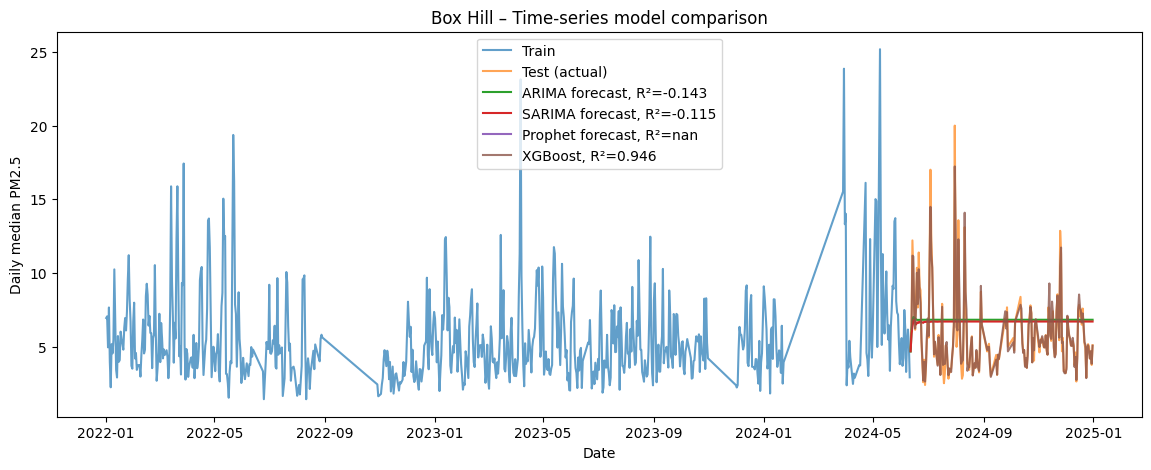


=== Site: Geelong South ===


22:05:41 - cmdstanpy - INFO - Chain [1] start processing
22:05:41 - cmdstanpy - INFO - Chain [1] done processing
22:05:41 - cmdstanpy - ERROR - Chain [1] error: code '3221225785' 
Optimization terminated abnormally. Falling back to Newton.
22:05:41 - cmdstanpy - INFO - Chain [1] start processing
22:05:41 - cmdstanpy - INFO - Chain [1] done processing
22:05:41 - cmdstanpy - ERROR - Chain [1] error: code '3221225785' 


Prophet failed for Geelong South: Error during optimization! Command 'C:\Users\Christopher\Desktop\Personal Projects\Project 1 Comparing Melbourne's Air Quality\mel-air-norms-now\.venv\Lib\site-packages\prophet\stan_model\prophet_model.bin random seed=22496 data file=C:\Users\CHRIST~1\AppData\Local\Temp\tmpr8vm9ldk\6l6wymvt.json init=C:\Users\CHRIST~1\AppData\Local\Temp\tmpr8vm9ldk\9ydznudx.json output file=C:\Users\CHRIST~1\AppData\Local\Temp\tmpr8vm9ldk\prophet_modell7xjlosb\prophet_model-20251129220541.csv method=optimize algorithm=newton iter=10000' failed: 

=== Site: Melton ===


22:05:44 - cmdstanpy - INFO - Chain [1] start processing
22:05:44 - cmdstanpy - INFO - Chain [1] done processing
22:05:44 - cmdstanpy - ERROR - Chain [1] error: code '3221225785' 
Optimization terminated abnormally. Falling back to Newton.
22:05:44 - cmdstanpy - INFO - Chain [1] start processing
22:05:44 - cmdstanpy - INFO - Chain [1] done processing
22:05:44 - cmdstanpy - ERROR - Chain [1] error: code '3221225785' 


Prophet failed for Melton: Error during optimization! Command 'C:\Users\Christopher\Desktop\Personal Projects\Project 1 Comparing Melbourne's Air Quality\mel-air-norms-now\.venv\Lib\site-packages\prophet\stan_model\prophet_model.bin random seed=49700 data file=C:\Users\CHRIST~1\AppData\Local\Temp\tmpr8vm9ldk\z1h2dizj.json init=C:\Users\CHRIST~1\AppData\Local\Temp\tmpr8vm9ldk\x3245lyb.json output file=C:\Users\CHRIST~1\AppData\Local\Temp\tmpr8vm9ldk\prophet_modeltp5expkz\prophet_model-20251129220544.csv method=optimize algorithm=newton iter=10000' failed: 

=== Site: Morwell South ===


...

Prophet failed for Newborough: Error during optimization! Command 'C:\Users\Christopher\Desktop\Personal Projects\Project 1 Comparing Melbourne's Air Quality\mel-air-norms-now\.venv\Lib\site-packages\prophet\stan_model\prophet_model.bin random seed=88893 data file=C:\Users\CHRIST~1\AppData\Local\Temp\tmpr8vm9ldk\z2n5cxic.json init=C:\Users\CHRIST~1\AppData\Local\Temp\tmpr8vm9ldk\f6_1oxp5.json output file=C:\Users\CHRIST~1\AppData\Local\Temp\tmpr8vm9ldk\prophet_model1x92wsac\prophet_model-20251129220555.csv method=optimize algorithm=newton iter=10000' failed: 

=== Site: Campbellfield ===


22:05:56 - cmdstanpy - INFO - Chain [1] start processing
22:05:56 - cmdstanpy - INFO - Chain [1] done processing
22:05:56 - cmdstanpy - ERROR - Chain [1] error: code '3221225785' 


Prophet failed for Campbellfield: Error during optimization! Command 'C:\Users\Christopher\Desktop\Personal Projects\Project 1 Comparing Melbourne's Air Quality\mel-air-norms-now\.venv\Lib\site-packages\prophet\stan_model\prophet_model.bin random seed=32788 data file=C:\Users\CHRIST~1\AppData\Local\Temp\tmpr8vm9ldk\jyq1siz1.json init=C:\Users\CHRIST~1\AppData\Local\Temp\tmpr8vm9ldk\nk3b_b_k.json output file=C:\Users\CHRIST~1\AppData\Local\Temp\tmpr8vm9ldk\prophet_modelc99mg2op\prophet_model-20251129220556.csv method=optimize algorithm=newton iter=10000' failed: 

=== Site: Bendigo ===


22:05:58 - cmdstanpy - INFO - Chain [1] start processing
22:05:58 - cmdstanpy - INFO - Chain [1] done processing
22:05:58 - cmdstanpy - ERROR - Chain [1] error: code '3221225785' 
Optimization terminated abnormally. Falling back to Newton.
22:05:58 - cmdstanpy - INFO - Chain [1] start processing
22:05:58 - cmdstanpy - INFO - Chain [1] done processing
22:05:58 - cmdstanpy - ERROR - Chain [1] error: code '3221225785' 


Prophet failed for Bendigo: Error during optimization! Command 'C:\Users\Christopher\Desktop\Personal Projects\Project 1 Comparing Melbourne's Air Quality\mel-air-norms-now\.venv\Lib\site-packages\prophet\stan_model\prophet_model.bin random seed=47053 data file=C:\Users\CHRIST~1\AppData\Local\Temp\tmpr8vm9ldk\yj105p9z.json init=C:\Users\CHRIST~1\AppData\Local\Temp\tmpr8vm9ldk\o32z05l4.json output file=C:\Users\CHRIST~1\AppData\Local\Temp\tmpr8vm9ldk\prophet_modeliqauc4cs\prophet_model-20251129220558.csv method=optimize algorithm=newton iter=10000' failed: 


In [18]:
all_site_metrics = []

example_site_for_plots = "Box Hill"

for site in sites:
    print(f"\n=== Site: {site} ===")

    # ARIMA/SARIMA/Prophet: Univariate series
    site_df = (
        df_pm25[df_pm25["site_name"] == site]
        .sort_values("date")
        .reset_index(drop=True)
    )

    y_series = site_df["daily_median"].astype(float)
    dates = site_df["date"]

    n = len(y_series)
    split_idx = int((1 - test_frac) * n)

    y_train, y_test = y_series.iloc[:split_idx], y_series.iloc[split_idx:]
    dates_train, dates_test = dates.iloc[:split_idx], dates.iloc[split_idx:]

    # ARIMA
    try:
        arima_model = ARIMA(y_train, order=arima_order)
        arima_res = arima_model.fit()
        arima_forecast = arima_res.forecast(steps=len(y_test))
        mae_arima, rmse_arima, r2_arima = eval_forecast(y_test, arima_forecast)
    except Exception as e:
        print(f"ARIMA failed for {site}: {e}")
        mae_prophet = rmse_prophet = r2_prophet = np.nan
        prophet_pred = np.full(len(y_test), np.nan)

    # SARIMA 
    try:
        sarima_model = SARIMAX(
            y_train,
            order=sarima_order,
            seasonal_order=sarima_seasonal,
            enforce_stationarity=False,
            enforce_invertibility=False,
        )
        sarima_res = sarima_model.fit(disp=False)
        sarima_forecast = sarima_res.forecast(steps=len(y_test))
        mae_sarima, rmse_sarima, r2_sarima = eval_forecast(y_test, sarima_forecast)
    except Exception as e:
        print(f"SARIMA failed for {site}: {e}")
        mae_sarima = rmse_sarima = r2_sarima = np.nan
        sarima_forecast = pd.Series(index=y_test.index, data=np.nan)

    # Prophet 
    try:
        # Prophet needs a clean date + y dataframe
        df_prophet = pd.DataFrame({
            "ds": dates,
            "y": y_series,
        })

        df_prophet_train = df_prophet.iloc[:split_idx].copy()
        df_prophet_test = df_prophet.iloc[split_idx:].copy()

        m = Prophet()
        m.fit(df_prophet_train)

        future = df_prophet_test[["ds"]]  # forecast exactly on test dates
        forecast_prophet = m.predict(future)
        prophet_pred = forecast_prophet["yhat"].values

        mae_prophet, rmse_prophet, r2_prophet = eval_forecast(
            df_prophet_test["y"].values, prophet_pred
        )
    except Exception as e:
        print(f"Prophet failed for {site}: {e}")
        mae_prophet = rmse_prophet = r2_prophet = np.nan
        prophet_pred = np.full(len(y_test), np.nan)

    # XGBoost with all lag features
    # use df_lagged (no missing lags) but subset for this site
    site_lagged = (
        df_lagged[df_lagged["site_name"] == site]
        .sort_values("date")
        .reset_index(drop=True)
    )

    X_site = site_lagged[xgb_features].astype(float)
    y_site = site_lagged["daily_median"].astype(float)

    n_lag = len(y_site)
    split_idx_lag = int((1 - test_frac) * n_lag)

    X_train_xgb, X_test_xgb = X_site.iloc[:split_idx_lag], X_site.iloc[split_idx_lag:]
    y_train_xgb, y_test_xgb = y_site.iloc[:split_idx_lag], y_site.iloc[split_idx_lag:]

    try:
        xgb = XGBRegressor(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="reg:squarederror",
            random_state=42,
            n_jobs=-1,
        )
        xgb.fit(X_train_xgb, y_train_xgb)
        xgb_pred = xgb.predict(X_test_xgb)

        mae_xgb, rmse_xgb, r2_xgb = eval_forecast(y_test_xgb, xgb_pred)
    except Exception as e:
        print(f"XGBoost failed for {site}: {e}")
        mae_xgb = rmse_xgb = r2_xgb = np.nan
        xgb_pred = np.full(len(y_test_xgb), np.nan)

    # Save metrics
    all_site_metrics.append({
        "site": site,
        "mae_arima": mae_arima,
        "rmse_arima": rmse_arima,
        "r2_arima": r2_arima,
        "mae_sarima": mae_sarima,
        "rmse_sarima": rmse_sarima,
        "r2_sarima": r2_sarima,
        "mae_prophet": mae_prophet,
        "rmse_prophet": rmse_prophet,
        "r2_prophet": r2_prophet,
        "mae_xgb": mae_xgb,
        "rmse_xgb": rmse_xgb,
        "r2_xgb": r2_xgb,
    })

    # Plot for one example site
    if site == example_site_for_plots:
        plt.figure(figsize=(14, 5))
        plt.plot(dates_train, y_train, label="Train", alpha=0.7)
        plt.plot(dates_test, y_test, label="Test (actual)", alpha=0.7)

        plt.plot(dates_test, arima_forecast, label=f"ARIMA forecast, R²={r2_arima:.3f}")
        plt.plot(dates_test, sarima_forecast, label=f"SARIMA forecast, R²={r2_sarima:.3f}")
        plt.plot(dates_test, prophet_pred, label=f"Prophet forecast, R²={r2_prophet:.3f}")

        # for XGBoost we have slightly fewer rows because of lag dropping
        # align its test dates from site_lagged
        dates_lag_test = site_lagged["date"].iloc[split_idx_lag:]
        plt.plot(dates_lag_test, xgb_pred, label=f"XGBoost, R²={r2_xgb:.3f}", alpha=0.8)

        plt.legend()
        plt.title(f"{site} – Time-series model comparison")
        plt.ylabel("Daily median PM2.5")
        plt.xlabel("Date")
        plt.show()

In [ ]:
# First, merge the two metric tables on 'site'

In [19]:
metrics_ts = pd.DataFrame(all_site_metrics)
metrics_ts

,site,mae_arima,rmse_arima,r2_arima,mae_sarima,rmse_sarima,r2_sarima,mae_prophet,rmse_prophet,r2_prophet,mae_xgb,rmse_xgb,r2_xgb
0,Alphington,3.366867,4.978443,-0.022647,3.365876,4.978964,-0.022861,NaN,NaN,NaN,0.451420,0.952192,0.962653
1,Footscray,2.286127,2.944946,-0.006959,2.433570,2.982958,-0.033122,NaN,NaN,NaN,0.243544,0.407723,0.980688
2,Brighton,2.441379,3.121444,-0.002429,2.463354,3.127702,-0.006452,NaN,NaN,NaN,0.359838,0.638235,0.958293
3,Traralgon,2.060534,2.851291,-0.010382,2.057449,2.852930,-0.011544,NaN,NaN,NaN,0.324223,0.546646,0.962862
4,Morwell East,1.668630,2.059948,-0.033153,2.409255,2.868980,-1.004045,NaN,NaN,NaN,2.155036,5.889597,-7.445462
5,Dandenong,1.909027,2.343096,-0.128804,1.903251,2.341344,-0.127116,NaN,NaN,NaN,0.386083,0.574238,0.932201
6,Box Hill,2.211423,2.790931,-0.142528,2.157153,2.757096,-0.114994,NaN,NaN,NaN,0.343658,0.609818,0.945732
7,Geelong South,1.563770,2.008674,-0.007546,1.674988,2.071091,-0.071135,NaN,NaN,NaN,0.287028,1.224612,0.625678
8,Melton,1.684043,2.150595,-0.003331,1.700923,2.162323,-0.014304,NaN,NaN,NaN,0.307561,0.439404,0.958115
9,Morwell South,1.455595,1.707403,-0.183123,1.679745,1.962008,-0.562283,NaN,NaN,NaN,0.149019,0.204006,0.983110


In [21]:
summary_by_model = pd.DataFrame({
    "model": ["ARIMA", "SARIMA", "Prophet", "XGBoost"],
    "MAE": [
        metrics_ts["mae_arima"].mean(),
        metrics_ts["mae_sarima"].mean(),
        metrics_ts["mae_prophet"].mean(),
        metrics_ts["mae_xgb"].mean(),
    ],
    "RMSE": [
        metrics_ts["rmse_arima"].mean(),
        metrics_ts["rmse_sarima"].mean(),
        metrics_ts["rmse_prophet"].mean(),
        metrics_ts["rmse_xgb"].mean(),
    ],
    "R2": [
        metrics_ts["r2_arima"].mean(),
        metrics_ts["r2_sarima"].mean(),
        metrics_ts["r2_prophet"].mean(),
        metrics_ts["r2_xgb"].mean(),
    ],
})
summary_by_model


,model,MAE,RMSE,R2
0,ARIMA,2.122966,2.813045,-0.103609
1,SARIMA,2.266063,2.957135,-0.252875
2,Prophet,NaN,NaN,NaN
3,XGBoost,0.483637,1.150862,0.252679
